# TN3 — Quét toàn dải alpha, DS-TCN 64 kênh tầm nhìn 121

Cấu hình thứ ba của TN3, bên cạnh `c64 k3 RF61` và `c192 k5 RF121`.

## Vì sao chạy thêm cấu hình này

Hai cấu hình TN3 đã xong cho cùng một kết luận về phần "có lai thì hơn MSE
thuần" — **20/20 mức alpha**, ở hai kích cỡ model cách nhau 8,3 lần tham số.
Nhưng chúng **không** cho cùng thứ hạng: tốp 3 của c64 k3 là 0,6 · 0,5 · 0,4
còn của c192 k5 là 0,2 · 0,3 · 0,0, không giao nhau mức nào.

Cấu hình này tách được hai biến đang dính vào nhau. So với `c64 k3` nó khác
đúng **tầm nhìn**; so với `c192 k5` nó khác đúng **số kênh**. Nên bảng thứ ba
trả lời được: thứ hạng alpha đổi theo tầm nhìn, theo số kênh, hay chỉ là nhiễu.

## Cấu hình nền

| | |
|---|---|
| model | `ds_tcn --channels 64 --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element` |
| tham số | **38.105** |
| tầm nhìn | 121 — phủ 60% cửa sổ vào, và 121% một pha thở |
| MSE thuần, alpha 1,0 | **0,757855** *(TN2, 4 fold, 1 seed)* |

`alpha = 1,0` **không chạy** — đó chính là MSE thuần, TN2 đã đo bằng đúng cấu
hình và đúng bốn fold này. Ô so sánh ở mục 5 tự chèn nó làm điểm tham chiếu.

## Chi phí

Đo từ dấu thời gian của TN3 c64 đã chạy: **khoảng 15 phút một fold**, tức
**~1 giờ một mức alpha**. Mười mức khoảng **10 giờ**.

**Không cần chạy hết một lần.** Mỗi alpha một ô riêng, và ô train nào cũng nén
lên Drive ngay sau khi xong. Dừng lúc nào cũng được: mở lại, chạy ô khôi phục ở
mục 1 rồi bấm tiếp ô còn thiếu. `run_cv.py` bỏ qua mọi fold đã xong.

Muốn thấy hình dạng sớm thì chạy thưa trước: **0,0 → 0,5 → 0,9 → 0,2 → 0,7**,
rồi lấp các điểm còn lại sau.

## Đọc kết quả

Một seed. `seed_std` của các cấu hình TN1 trải 0,0007–0,0108, mà biên độ dao
động bên trong mỗi cột TN3 đã đo được là 0,0151 và 0,0107 — cùng cỡ. Nên
**chênh lệch giữa hai alpha liền kề không đọc được**; thứ đọc được là *mọi mức
alpha có hơn MSE thuần hay không*, và *hình dạng chung của đường cong*.

## 1. Chuẩn bị Colab

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Tải mã nguồn.

In [2]:
!rm -rf /content/UWB_RADAR
!git clone -q --branch submission --single-branch https://github.com/quangminhho004-blip/UWB_RADAR.git /content/UWB_RADAR
%cd /content/UWB_RADAR
!python scripts/setup_colab.py

/content/UWB_RADAR

thư mục làm việc : /content/UWB_RADAR
commit đồ án     : 0f919b7
commit MobiVital : 4319731 (đã ghim)
GPU              : NVIDIA L4, 23034 MiB


Lấy `by_user/` và `windows/` từ Drive.

In [3]:
!python scripts/restore_processed_data_on_drive.py

by_user   : bung /content/drive/MyDrive/mobivital/by_user.tar ...
            12 tệp
windows   : bung /content/drive/MyDrive/mobivital/windows.tar.gz ...
            dev_cv 8 tệp, final_train có

2.5G	data/processed/by_user
503M	data/processed/windows


Khôi phục mọi mức alpha đã chạy.

**Chạy ô này mỗi khi mở lại notebook.** Nó gộp `runs/*/summary.csv` vào `runs/summary.csv` — chỗ `run_cv.py` tra để biết fold nào đã xong. Mẫu tên tệp bắt cả `c64_k3` lẫn `c64_k5`; hai bộ có `run_id` khác nhau nên gộp chung vô hại, còn bảng ở mục 5 lọc riêng `_c64_k5_`.

In [4]:
# Khôi phục kết quả đã chạy trước khi phiên bị ngắt.
#
# Mỗi tệp nén chứa một bản runs/<thực nghiệm>/summary.csv của riêng nó. Giải
# hết vào cùng một thư mục runs/ thì tệp giải sau ĐÈ summary.csv của tệp trước.
# Mà sorted() xếp "..._a0_corr0.9..." đứng SAU "..._a0.9_corr0.9...", vì trong
# bảng mã ký tự "_" lớn hơn "." — nên bản ít dòng nhất lại là bản đè cuối cùng.
# Sửa: mỗi tệp nén giải vào một thư mục tạm riêng, gộp mọi dòng lại rồi mới ghi
# runs/summary.csv một lần. Thứ tự giải nén không còn ảnh hưởng gì nữa.
import csv, glob, os, shutil, subprocess, tempfile

MAU_ZIP = "/content/drive/MyDrive/mobivital/tn3_*c64*.zip"

rows, seen = [], set()

def collect(summary_path):
    for r in csv.DictReader(open(summary_path)):
        key = (r.get("experiment"), r.get("run_id"))
        if key not in seen:
            seen.add(key)
            rows.append(r)

for f in sorted(glob.glob(MAU_ZIP)):
    tmp = tempfile.mkdtemp()
    subprocess.run(["unzip", "-oq", f, "-d", tmp], check=True)
    for s in glob.glob(tmp + "/*/summary.csv"):
        collect(s)
        os.remove(s)   # gộp xong thì bỏ, để bước chép dưới không đè nhau nữa
    # Checkpoint và curve.csv nằm trong thư mục riêng của từng lần chạy, tên
    # không trùng nhau, nên chép chồng lên runs/ là an toàn.
    for d in os.listdir(tmp):
        shutil.copytree(tmp + "/" + d, "runs/" + d, dirs_exist_ok=True)
    shutil.rmtree(tmp)

# Dòng đã sinh ra trong chính phiên này cũng phải giữ lại.
if os.path.exists("runs/summary.csv"):
    collect("runs/summary.csv")

if rows:
    # run_cv.py tra runs/summary.csv, còn tệp nén chỉ có runs/<thực nghiệm>/summary.csv
    cols = []
    for r in rows:
        for k in r:
            if k not in cols:
                cols.append(k)
    with open("runs/summary.csv", "w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=cols, restval="")
        w.writeheader()
        w.writerows(rows)
print("khôi phục", len(rows), "dòng vào runs/summary.csv")

khôi phục 50 dòng vào runs/summary.csv


## 2. Kiểm bản cài đặt

Số tham số phải ra đúng **38.105**.

In [5]:
!python scripts/check_model.py --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element

Kiểm model: ds_tcn

1. Hình dạng vào ra và giá trị
   vào (4, 200)  ->  ra (4, 25)
   ra đúng (4, 25)                                            đạt
   mọi giá trị hữu hạn                                        đạt

2. Gradient
   36/36 tham số nhận được gradient
   mọi tham số đều lan ngược tới                              đạt

3. Số tham số
   38105

4. Lưu và nạp lại state_dict
   nạp lại cho ra đúng đầu ra cũ                              đạt

5. Riêng TCN
   0 lớp BatchNorm1d, WeightNorm: False
   KHÔNG có lớp chuẩn hoá nào, đúng cấu hình đã chọn          đạt
   cũng không có WeightNorm                                   đạt

6. Loại dropout
   0 lớp Dropout1d (xoá cả kênh), 8 lớp Dropout (xoá từng phần tử)
   dùng nn.Dropout, xoá từng phần tử                          đạt

7. Tầm nhìn so với cửa sổ vào
   kernel 5, 4 khối -> tầm nhìn 121, cửa sổ vào 200
   CHÚ Ý: chỉ thấy 121/200 mẫu gần nhất, mất 40% đầu cửa sổ
   tầm nhìn ngắn hơn cửa sổ — có chủ ý, không phải lỗi        đạt

TẤT 

## 3. Mười mức alpha, mỗi mức đủ 4 fold

Mỗi ô train xong tự nén lên Drive, nên đứt phiên chỉ mất mức đang chạy.

**alpha 0,0 — MSE 0 phần trăm, Pearson 100 phần trăm**  — **Pearson thuần**, khớp hoàn hảo với cách chấm điểm

In [6]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.0 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.39767  pearson 0.4740   0.4 phút
epoch  1  mse 0.37087  pearson 0.5339   0.8 phút
epoch  2  mse 0.35355  pearson 0.5492   1.2 phút
epoch  3  mse 0.34964  pearson 0.5603   1.6 phút
epoch  4  mse 0.35441  pearson 0.5664   2.0 phút
epoch  5  mse 0.36013  pearson 0.5706   2.4 phút
epoch  6  mse 0.36774  pearson 0.5737   2.8 phút
epoch  7  mse 0.36688  pearson 0.5773   3.2 phút
epoch  8  mse 0.36841  pearson 0.5804   3.6 phút
epoch  9  mse 0.36913  pearson 0.5821   4.0 phút
epoch 10  mse 0.36932  pearson 0.5850   4.4 phút
epoch 11  mse 0.37064  pearson 0.5871   4.8 phút
epoch 12  mse 0.36355  pearson 0.5890   5.2 phút
epoch 13  mse 0.36181  pearson 0.5916   5.6 phút
epoch 14  mse 0.35940  pearson 0.5936   6.0 phút
epoch 15  mse 0.35832  pearson 0.5

**alpha 0,1 — MSE 10 phần trăm, Pearson 90 phần trăm**

In [7]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.1 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.1_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.14259  pearson 0.4743   0.4 phút
epoch  1  mse 0.06812  pearson 0.5337   0.8 phút
epoch  2  mse 0.05954  pearson 0.5497   1.2 phút
epoch  3  mse 0.05698  pearson 0.5602   1.6 phút
epoch  4  mse 0.05572  pearson 0.5669   2.0 phút
epoch  5  mse 0.05409  pearson 0.5707   2.4 phút
epoch  6  mse 0.05252  pearson 0.5751   2.8 phút
epoch  7  mse 0.05119  pearson 0.5785   3.1 phút
epoch  8  mse 0.04978  pearson 0.5814   3.5 phút
epoch  9  mse 0.04845  pearson 0.5838   3.9 phút
epoch 10  mse 0.04739  pearson 0.5873   4.3 phút
epoch 11  mse 0.04616  pearson 0.5897   4.7 phút
epoch 12  mse 0.04546  pearson 0.5921   5.1 phút
epoch 13  mse 0.04508  pearson 0.5938   5.5 phút
epoch 14  mse 0.04447  pearson 0.5951   5.9 phút
epoch 15  mse 0.04397  pearson 0

**alpha 0,2 — MSE 20 phần trăm, Pearson 80 phần trăm**

In [8]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.2 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.2_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.10694  pearson 0.4739   0.4 phút
epoch  1  mse 0.05445  pearson 0.5337   0.8 phút
epoch  2  mse 0.05080  pearson 0.5494   1.2 phút
epoch  3  mse 0.04879  pearson 0.5596   1.6 phút
epoch  4  mse 0.04697  pearson 0.5662   2.1 phút
epoch  5  mse 0.04516  pearson 0.5706   2.5 phút
epoch  6  mse 0.04338  pearson 0.5750   2.9 phút
epoch  7  mse 0.04179  pearson 0.5788   3.3 phút
epoch  8  mse 0.04035  pearson 0.5817   3.7 phút
epoch  9  mse 0.03890  pearson 0.5843   4.1 phút
epoch 10  mse 0.03803  pearson 0.5870   4.5 phút
epoch 11  mse 0.03690  pearson 0.5894   4.9 phút
epoch 12  mse 0.03631  pearson 0.5914   5.3 phút
epoch 13  mse 0.03544  pearson 0.5922   5.7 phút
epoch 14  mse 0.03471  pearson 0.5942   6.1 phút
epoch 15  mse 0.03398  pearson 0

**alpha 0,3 — MSE 30 phần trăm, Pearson 70 phần trăm**

In [9]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.3 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.3_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.09031  pearson 0.4731   0.4 phút
epoch  1  mse 0.04914  pearson 0.5347   0.8 phút
epoch  2  mse 0.04576  pearson 0.5498   1.2 phút
epoch  3  mse 0.04309  pearson 0.5592   1.6 phút
epoch  4  mse 0.04081  pearson 0.5657   2.0 phút
epoch  5  mse 0.03888  pearson 0.5704   2.4 phút
epoch  6  mse 0.03714  pearson 0.5748   2.8 phút
epoch  7  mse 0.03563  pearson 0.5791   3.2 phút
epoch  8  mse 0.03457  pearson 0.5819   3.6 phút
epoch  9  mse 0.03353  pearson 0.5842   4.0 phút
epoch 10  mse 0.03268  pearson 0.5869   4.4 phút
epoch 11  mse 0.03221  pearson 0.5891   4.8 phút
epoch 12  mse 0.03165  pearson 0.5916   5.2 phút
epoch 13  mse 0.03102  pearson 0.5924   5.6 phút
epoch 14  mse 0.03059  pearson 0.5942   6.1 phút
epoch 15  mse 0.03011  pearson 0

**alpha 0,4 — MSE 40 phần trăm, Pearson 60 phần trăm**

In [10]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.4 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.4_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.08065  pearson 0.4714   0.4 phút
epoch  1  mse 0.04472  pearson 0.5344   0.8 phút
epoch  2  mse 0.04100  pearson 0.5496   1.2 phút
epoch  3  mse 0.03862  pearson 0.5592   1.6 phút
epoch  4  mse 0.03637  pearson 0.5665   2.0 phút
epoch  5  mse 0.03447  pearson 0.5713   2.4 phút
epoch  6  mse 0.03303  pearson 0.5757   2.8 phút
epoch  7  mse 0.03186  pearson 0.5800   3.2 phút
epoch  8  mse 0.03104  pearson 0.5825   3.6 phút
epoch  9  mse 0.03013  pearson 0.5854   4.0 phút
epoch 10  mse 0.02967  pearson 0.5881   4.4 phút
epoch 11  mse 0.02913  pearson 0.5903   4.8 phút
epoch 12  mse 0.02876  pearson 0.5925   5.2 phút
epoch 13  mse 0.02828  pearson 0.5937   5.6 phút
epoch 14  mse 0.02790  pearson 0.5955   6.0 phút
epoch 15  mse 0.02755  pearson 0

**alpha 0,5 — MSE 50 phần trăm, Pearson 50 phần trăm**

In [11]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.5 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.5_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.07333  pearson 0.4686   0.4 phút
epoch  1  mse 0.04081  pearson 0.5331   0.8 phút
epoch  2  mse 0.03742  pearson 0.5497   1.2 phút
epoch  3  mse 0.03513  pearson 0.5601   1.6 phút
epoch  4  mse 0.03311  pearson 0.5677   2.0 phút
epoch  5  mse 0.03162  pearson 0.5727   2.4 phút
epoch  6  mse 0.03051  pearson 0.5779   2.9 phút
epoch  7  mse 0.02969  pearson 0.5825   3.3 phút
epoch  8  mse 0.02907  pearson 0.5849   3.7 phút
epoch  9  mse 0.02844  pearson 0.5883   4.1 phút
epoch 10  mse 0.02805  pearson 0.5910   4.5 phút
epoch 11  mse 0.02763  pearson 0.5935   4.9 phút
epoch 12  mse 0.02740  pearson 0.5947   5.3 phút
epoch 13  mse 0.02712  pearson 0.5964   5.7 phút
epoch 14  mse 0.02673  pearson 0.5979   6.1 phút
epoch 15  mse 0.02653  pearson 0

**alpha 0,6 — MSE 60 phần trăm, Pearson 40 phần trăm**

In [12]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.6 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.6_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.06751  pearson 0.4656   0.4 phút
epoch  1  mse 0.03719  pearson 0.5336   0.8 phút
epoch  2  mse 0.03382  pearson 0.5516   1.2 phút
epoch  3  mse 0.03167  pearson 0.5628   1.6 phút
epoch  4  mse 0.03029  pearson 0.5704   2.0 phút
epoch  5  mse 0.02914  pearson 0.5755   2.4 phút
epoch  6  mse 0.02839  pearson 0.5803   2.8 phút
epoch  7  mse 0.02765  pearson 0.5848   3.2 phút
epoch  8  mse 0.02728  pearson 0.5868   3.6 phút
epoch  9  mse 0.02680  pearson 0.5896   4.0 phút
epoch 10  mse 0.02648  pearson 0.5921   4.3 phút
epoch 11  mse 0.02611  pearson 0.5946   4.7 phút
epoch 12  mse 0.02596  pearson 0.5953   5.1 phút
epoch 13  mse 0.02568  pearson 0.5969   5.5 phút
epoch 14  mse 0.02539  pearson 0.5981   5.9 phút
epoch 15  mse 0.02526  pearson 0

**alpha 0,7 — MSE 70 phần trăm, Pearson 30 phần trăm**

In [13]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.7 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.7_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.06290  pearson 0.4600   0.4 phút
epoch  1  mse 0.03468  pearson 0.5314   0.8 phút
epoch  2  mse 0.03150  pearson 0.5525   1.2 phút
epoch  3  mse 0.02959  pearson 0.5644   1.6 phút
epoch  4  mse 0.02840  pearson 0.5730   2.0 phút
epoch  5  mse 0.02749  pearson 0.5785   2.4 phút
epoch  6  mse 0.02681  pearson 0.5832   2.8 phút
epoch  7  mse 0.02620  pearson 0.5876   3.2 phút
epoch  8  mse 0.02591  pearson 0.5900   3.7 phút
epoch  9  mse 0.02548  pearson 0.5921   4.1 phút
epoch 10  mse 0.02522  pearson 0.5944   4.5 phút
epoch 11  mse 0.02499  pearson 0.5972   4.9 phút
epoch 12  mse 0.02489  pearson 0.5980   5.3 phút
epoch 13  mse 0.02467  pearson 0.5996   5.7 phút
epoch 14  mse 0.02449  pearson 0.6009   6.1 phút
epoch 15  mse 0.02436  pearson 0

**alpha 0,8 — MSE 80 phần trăm, Pearson 20 phần trăm**

In [14]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.8 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.8_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.05916  pearson 0.4514   0.4 phút
epoch  1  mse 0.03230  pearson 0.5304   0.8 phút
epoch  2  mse 0.02920  pearson 0.5556   1.2 phút
epoch  3  mse 0.02744  pearson 0.5690   1.6 phút
epoch  4  mse 0.02643  pearson 0.5769   2.0 phút
epoch  5  mse 0.02568  pearson 0.5818   2.4 phút
epoch  6  mse 0.02512  pearson 0.5859   2.8 phút
epoch  7  mse 0.02473  pearson 0.5897   3.2 phút
epoch  8  mse 0.02455  pearson 0.5914   3.6 phút
epoch  9  mse 0.02423  pearson 0.5936   4.0 phút
epoch 10  mse 0.02405  pearson 0.5952   4.4 phút
epoch 11  mse 0.02382  pearson 0.5976   4.8 phút
epoch 12  mse 0.02370  pearson 0.5981   5.2 phút
epoch 13  mse 0.02355  pearson 0.5998   5.6 phút
epoch 14  mse 0.02340  pearson 0.6008   6.0 phút
epoch 15  mse 0.02328  pearson 0

**alpha 0,9 — MSE 90 phần trăm, Pearson 10 phần trăm**

In [15]:
!python scripts/run_cv.py --experiment tn3 --model ds_tcn --channels 64 \
    --kernel_size 5 --n_blocks 4 --dropout 0.2 --norm none --dropout_kind element \
    --loss mse_pearson --alpha 0.9 --seed 0
!python scripts/save_results.py tn3 --out tn3_ds_tcn_c64_k5

thực nghiệm tn3  -> runs/tn3/
cấu hình ds_tcn_c64_k5_n4_none_do0.2_dpel_mse_pearson_a0.9_corr0.9_seed0
thiết bị  NVIDIA L4

----------------------------------------------------------
val_AB  train CDEFKL  chấm AB
210964 cửa sổ train
epoch  0  mse 0.05597  pearson 0.4344   0.4 phút
epoch  1  mse 0.02968  pearson 0.5325   0.8 phút
epoch  2  mse 0.02675  pearson 0.5620   1.2 phút
epoch  3  mse 0.02540  pearson 0.5736   1.6 phút
epoch  4  mse 0.02460  pearson 0.5801   2.0 phút
epoch  5  mse 0.02411  pearson 0.5841   2.4 phút
epoch  6  mse 0.02372  pearson 0.5882   2.8 phút
epoch  7  mse 0.02339  pearson 0.5911   3.2 phút
epoch  8  mse 0.02327  pearson 0.5928   3.6 phút
epoch  9  mse 0.02302  pearson 0.5944   4.0 phút
epoch 10  mse 0.02290  pearson 0.5961   4.4 phút
epoch 11  mse 0.02274  pearson 0.5983   4.8 phút
epoch 12  mse 0.02268  pearson 0.5990   5.2 phút
epoch 13  mse 0.02255  pearson 0.6004   5.6 phút
epoch 14  mse 0.02243  pearson 0.6013   6.0 phút
epoch 15  mse 0.02231  pearson 0

## 4. Bảng alpha, kèm điểm tham chiếu

Cột bên phải là chênh so với MSE thuần của chính cấu hình này.

In [16]:
import csv, re, os
MSE_THUAN = 0.757855          # TN2, cùng cấu hình, 4 fold, 1 seed
d = {}
if os.path.exists("runs/tn3/summary.csv"):
    d = {float(re.search(r"_a([\d.]+)_", r["run_id"]).group(1)): float(r["score_macro"])
         for r in csv.DictReader(open("runs/tn3/summary.csv"))
         if r["fold"] == "TONG" and "_c64_k5_" in r["run_id"]}
d[1.0] = MSE_THUAN
for a in sorted(d):
    hon = "" if a == 1.0 else "  %+.4f" % (d[a] - MSE_THUAN)
    print("  alpha", a, " ", round(d[a], 6), "<- MSE thuần" if a == 1.0 else hon)

  alpha 0.0   0.780306   +0.0225
  alpha 0.1   0.763183   +0.0053
  alpha 0.2   0.771996   +0.0141
  alpha 0.3   0.776213   +0.0184
  alpha 0.4   0.771848   +0.0140
  alpha 0.5   0.763457   +0.0056
  alpha 0.6   0.752386   -0.0055
  alpha 0.7   0.761892   +0.0040
  alpha 0.8   0.760013   +0.0022
  alpha 0.9   0.758236   +0.0004
  alpha 1.0   0.757855 <- MSE thuần


## 5. Đường cong alpha

Text(0.5, 1.0, '0 = Pearson thuần, 1 = MSE thuần')

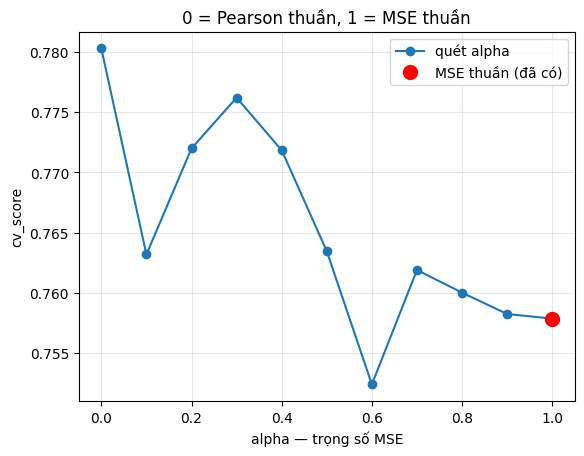

In [17]:
import matplotlib.pyplot as plt
x = sorted(d)
plt.plot(x, [d[i] for i in x], "o-", label="quét alpha")
plt.plot([1.0], [MSE_THUAN], "ro", ms=10, label="MSE thuần (đã có)")
plt.xlabel("alpha — trọng số MSE"); plt.ylabel("cv_score")
plt.legend(); plt.grid(alpha=.3); plt.title("0 = Pearson thuần, 1 = MSE thuần")

## 6. Ngắt phiên

In [ ]:
from google.colab import runtime
runtime.unassign()